### [Probability Distributions in Finance](https://medium.com/@simplifiedzone/be7ff7a7dfdc)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
np.set_printoptions(suppress=True, precision=4)

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

#### **The Normal (Gaussian) Distribution**

In [2]:
# ==========================================
# Hands-On: The Normal Distribution
# Context: Modeling Daily Stock Returns
# ==========================================

def run_normal_distribution_simulation():
    # 1. Setup Parameters
    # -------------------
    # We simulate a year of trading (252 days) for a volatile stock.
    # Mean return (mu) is usually close to 0 daily.
    # Volatility (sigma) is the standard deviation of returns.
    mean_daily_return = 0.0005  # Approx 0.05% daily return
    volatility = 0.02           # 2% daily volatility (high risk)
    num_days = 10000            # Simulating 10,000 days to get a smooth curve

    # 2. Generate Synthetic Data
    # -------------------
    # We assume returns follow a Normal Distribution N(mu, sigma)
    daily_returns = np.random.normal(loc=mean_daily_return,
                                     scale=volatility,
                                     size=num_days)

    # 3. Visualization
    # -------------------
    plt.figure(figsize=(10, 6))

    # Plot the Histogram (The "Empirical" Data)
    # 'density=True' normalizes the count to make it comparable to the PDF
    count, bins, ignored = plt.hist(daily_returns,
                                    bins=50,
                                    density=True,
                                    alpha=0.6,
                                    color='#2c3e50',
                                    label='Simulated Returns')

    # Plot the Theoretical PDF (The "Ideal" Bell Curve)
    # We calculate the probability density function for the x-axis range
    # standard deviation (sigma) is the 'scale', mean is 'loc'
    plt.plot(bins,
             stats.norm.pdf(bins, mean_daily_return, volatility),
             linewidth=3,
             color='#e74c3c',
             label='Theoretical Gaussian PDF')

    # 4. Analyze "Tail Events" (3-Sigma Rule)
    # -------------------
    # Calculate the 3-sigma thresholds
    sigma_down = mean_daily_return - (3 * volatility)
    sigma_up = mean_daily_return + (3 * volatility)

    plt.axvline(sigma_down, color='black', linestyle='--', label='-3 Sigma (Crash)')
    plt.axvline(sigma_up, color='black', linestyle='--', label='+3 Sigma (Spike)')

    # Add labels and formatting
    plt.title('The Gaussian Assumption: Simulated Returns vs. Theoretical Model', fontsize=14)
    plt.xlabel('Daily Return', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)

    print(f"--- Simulation Stats ---")
    print(f"Mean Return: {mean_daily_return:.4f}")
    print(f"Volatility:  {volatility:.4f}")
    print(f"3-Sigma Downside Threshold: {sigma_down:.4f} ({(sigma_down*100):.2f}%)")

    # Calculate how many days actually fell below -3 sigma
    crashes = np.sum(daily_returns < sigma_down)
    print(f"Number of 'Crash' days (<-3 sigma) in {num_days} days: {crashes}")
    print(f"Theoretical Expectation: {num_days * (1 - stats.norm.cdf(3)):.1f} days")

    plt.show()

--- Simulation Stats ---
Mean Return: 0.0005
Volatility:  0.0200
3-Sigma Downside Threshold: -0.0595 (-5.95%)
Number of 'Crash' days (<-3 sigma) in 10000 days: 15
Theoretical Expectation: 13.5 days


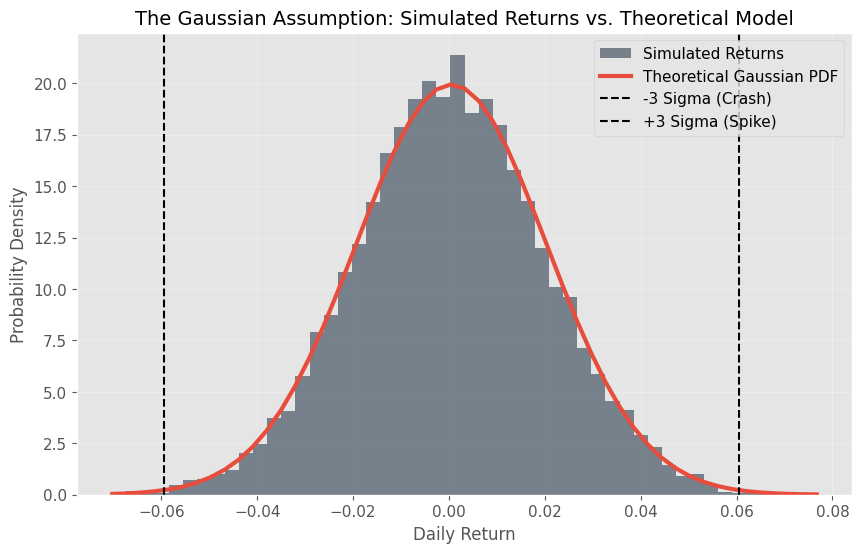

In [3]:
run_normal_distribution_simulation()

#### **The Lognormal Distribution**

In [4]:
# ==========================================
# Hands-On: The Lognormal Distribution
# Context: Modeling Future Stock Prices (Not Returns)
# ==========================================

def run_lognormal_simulation():
    # 1. Setup Parameters
    # -------------------
    # S0: Initial Stock Price
    # mu: Expected annual return (drift)
    # sigma: Annual Volatility
    S0 = 100.0
    mu = 0.05           # 5% expected growth
    sigma = 0.2         # 20% annual volatility
    num_simulations = 10000

    # 2. Generate Synthetic Prices
    # -------------------
    # According to theory, if returns are Normal, prices are Lognormal.
    # We simulate the price at the end of 1 year (T=1).
    # The formula for the underlying Normal variable parameters (M, S)
    # derived from geometric Brownian motion is:
    # M (location) = ln(S0) + (mu - 0.5 * sigma^2)
    # S (scale) = sigma

    normal_mean = np.log(S0) + (mu - 0.5 * sigma**2)
    normal_std = sigma

    # Generate 10,000 random end-of-year prices
    # We use the lognormal generator directly
    future_prices = np.random.lognormal(mean=normal_mean,
                                        sigma=normal_std,
                                        size=num_simulations)

    # 3. Visualization
    # -------------------
    plt.figure(figsize=(12, 6))

    # Plot the Histogram (Empirical Data)
    # Notice we use more bins to capture the long tail
    count, bins, ignored = plt.hist(future_prices,
                                    bins=100,
                                    density=True,
                                    alpha=0.6,
                                    color='#27ae60', # Green for Money/Price
                                    label='Simulated Future Prices')

    # Plot the Theoretical PDF
    # The x-axis represents Price ($), which must be > 0
    x = np.linspace(min(future_prices), max(future_prices), 1000)
    pdf = stats.lognorm.pdf(x, s=normal_std, scale=np.exp(normal_mean))

    plt.plot(x, pdf, linewidth=3, color='#c0392b', label='Theoretical Lognormal PDF')

    # 4. Critical Analysis: Skewness and Bounds
    # -------------------
    # Mark the initial price
    plt.axvline(S0, color='blue', linestyle='--', label=f'Start Price (${S0})')

    # Calculate Mean and Median to show Skewness
    sim_mean = np.mean(future_prices)
    sim_median = np.median(future_prices)

    plt.axvline(sim_mean, color='black', linestyle='-', label=f'Mean (${sim_mean:.2f})')

    plt.title('The Lognormal Reality: Asset Prices over Time', fontsize=14)
    plt.xlabel('Stock Price ($)', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Set x-axis limit to focus on the bulk of data, cutting off extreme outliers for readability
    # (Though the tail theoretically goes to infinity)
    plt.xlim(0, S0 * 2.5)

    print(f"--- Simulation Stats ---")
    print(f"Start Price: ${S0}")
    print(f"Mean End Price:   ${sim_mean:.2f} (Higher due to tail)")
    print(f"Median End Price: ${sim_median:.2f} (Most likely outcome)")
    print(f"Lowest Price Generated: ${min(future_prices):.2f} (Bounded by 0)")
    print(f"Highest Price Generated: ${max(future_prices):.2f} (The 'Lottery Ticket')")

    plt.show()

--- Simulation Stats ---
Start Price: $100.0
Mean End Price:   $104.98 (Higher due to tail)
Median End Price: $102.67 (Most likely outcome)
Lowest Price Generated: $43.15 (Bounded by 0)
Highest Price Generated: $214.12 (The 'Lottery Ticket')


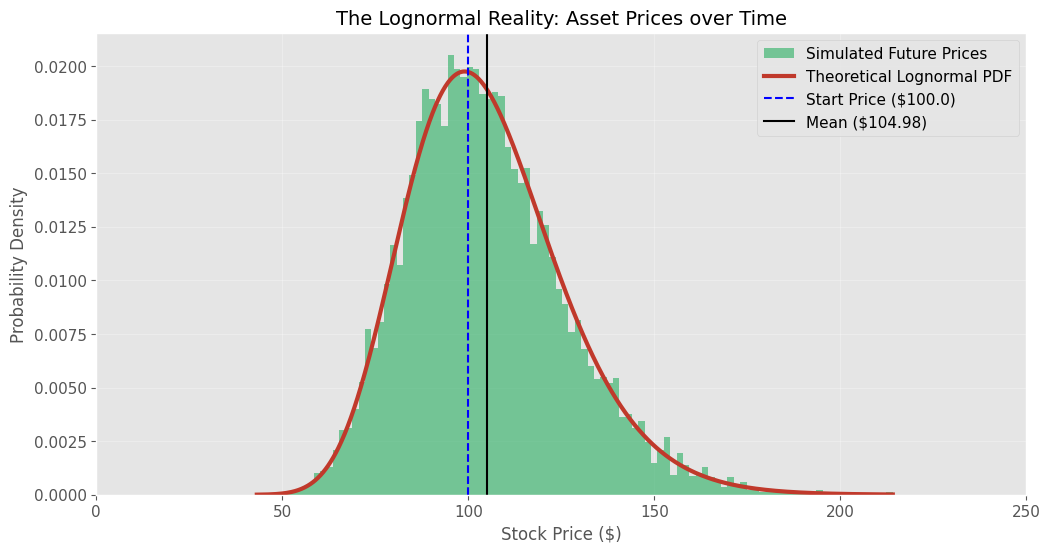

In [5]:
run_lognormal_simulation()

#### **The Inverse Normal (Inverse Gaussian) Distribution**

In [6]:
# ==========================================
# Hands-On: The Inverse Normal Distribution
# Context: "First Passage Time" (Barrier Options / Default Risk)
# ==========================================

def run_inverse_normal_simulation():
    # 1. Setup Parameters (The Drunkard's Path)
    # -------------------
    # We model a random walk with a positive drift.
    # Imagine a stock price or a firm's asset value trying to reach a level.

    num_simulations = 5000   # Number of "drunkards"
    barrier_level = 2.0      # The distance they need to travel (d)
    drift = 1.0              # Average speed (v)
    volatility = 1.0         # How much they stagger (sigma)

    # Simulation settings
    dt = 0.001               # Time step size (very small for accuracy)
    max_time = 15.0          # Max time to wait for them to cross
    num_steps = int(max_time / dt)

    print(f"Simulating {num_simulations} paths...")
    print(f"Target Barrier: {barrier_level}")
    print(f"Drift: {drift}, Volatility: {volatility}")

    # 2. Vectorized Brownian Motion Simulation
    # -------------------
    # We generate all random steps at once for speed.
    # dX = drift*dt + volatility*sqrt(dt)*Z

    # Generate random shocks (Z)
    random_shocks = np.random.normal(0, 1, (num_simulations, num_steps))

    # Calculate step increments
    steps = (drift * dt) + (volatility * np.sqrt(dt) * random_shocks)

    # Calculate cumulative positions (paths)
    # axis=1 means we sum across time for each simulation
    paths = np.cumsum(steps, axis=1)

    # 3. Find "First Passage Time"
    # -------------------
    # We need to find the *first* index where the path crosses the barrier.

    crossing_times = []

    # Create a boolean mask of where paths are above barrier
    crossings = paths >= barrier_level

    # argmax returns the index of the first True value
    # If no True value exists (never crosses), it returns 0
    first_crossing_indices = np.argmax(crossings, axis=1)

    for i in range(num_simulations):
        idx = first_crossing_indices[i]

        # Check if it actually crossed (idx > 0) or if it crossed at the very start (unlikely)
        # Also ensure the value at idx is actually >= barrier (handles "never crossed" case)
        if crossings[i, idx]:
            time_taken = idx * dt
            crossing_times.append(time_taken)

    crossing_times = np.array(crossing_times)
    print(f"Number of paths that hit the barrier: {len(crossing_times)}")

    # 4. Visualization
    # -------------------
    plt.figure(figsize=(12, 7))

    # A. Plot histogram of Hitting Times
    count, bins, ignored = plt.hist(crossing_times,
                                    bins=80,
                                    density=True,
                                    alpha=0.6,
                                    color='#8e44ad', # Purple for "Royal/Complex"
                                    label='Simulated Hitting Times')

    # B. Plot Theoretical Inverse Gaussian PDF
    # The formula for First Passage Time density is specific:
    # f(t) = (d / sqrt(2*pi*sigma^2*t^3)) * exp( -(d - v*t)^2 / (2*sigma^2*t) )

    t_values = np.linspace(min(bins), max(bins), 1000)

    # Calculate PDF manually to ensure it matches the physical parameters
    # (Scipy's invgauss parameterization can be tricky to map to drift/diffusion)
    numerator = barrier_level
    denominator = np.sqrt(2 * np.pi * (volatility**2) * (t_values**3))
    exponent_term = -((barrier_level - drift * t_values)**2) / (2 * (volatility**2) * t_values)

    pdf = (numerator / denominator) * np.exp(exponent_term)

    plt.plot(t_values, pdf, linewidth=3, color='#f1c40f', label='Theoretical Inverse Normal PDF')

    # Add labels
    plt.title(f'The Inverse Normal: Time to Reach Barrier {barrier_level}', fontsize=14)
    plt.xlabel('Time Needed (t)', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Add an inset or secondary calculation for Mean Time
    mean_theoretical = barrier_level / drift
    plt.axvline(mean_theoretical, color='black', linestyle='--', label=f'Expected Time ({mean_theoretical:.2f})')
    plt.legend()

    plt.show()

Simulating 5000 paths...
Target Barrier: 2.0
Drift: 1.0, Volatility: 1.0
Number of paths that hit the barrier: 5000


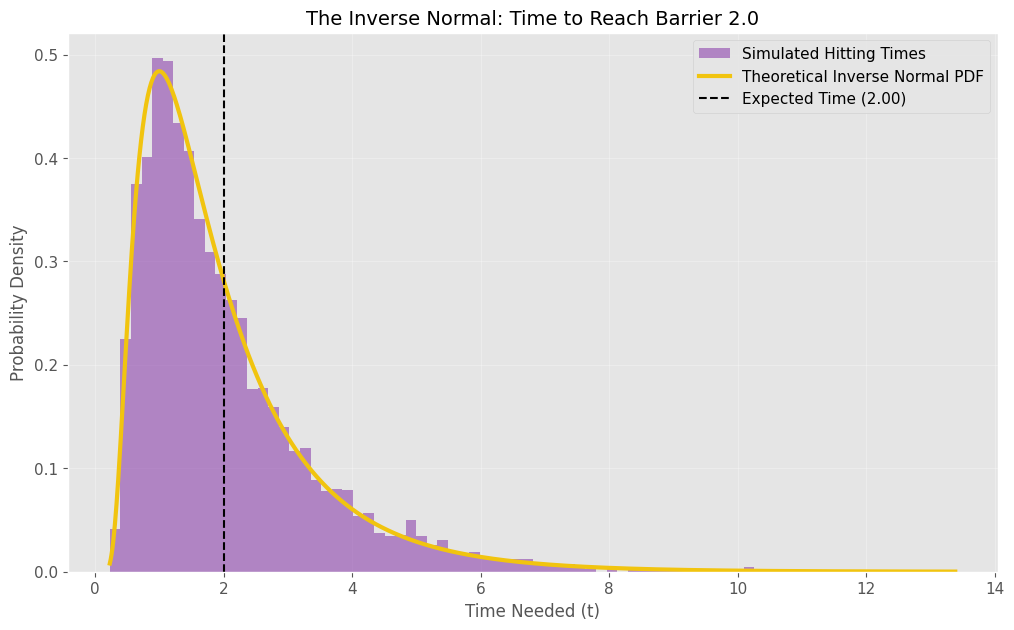

In [7]:
run_inverse_normal_simulation()